<a href="https://colab.research.google.com/github/imane-louzi/credit-scoring-model/blob/master/scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cs-training.csv.zip to cs-training.csv.zip


In [ ]:
import pandas as pd

df = pd.read_csv('cs-training.csv.zip', index_col=0, compression='zip')
print(df.shape)
df.head()


(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df.info()
df.isnull().sum()
df['SeriousDlqin2yrs'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

,proportion
SeriousDlqin2yrs,
0,0.93316
1,0.06684


In [ ]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
y_pred = model.predict(X_test_scaled)

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

AUC: 0.7995158272295027
              precision    recall  f1-score   support

           0       0.97      0.78      0.87     41992
           1       0.18      0.66      0.28      3008

    accuracy                           0.78     45000
   macro avg       0.58      0.72      0.58     45000
weighted avg       0.92      0.78      0.83     45000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)  # pas besoin de scaler pour un random forest

y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("AUC Random Forest:", roc_auc_score(y_test, y_pred_proba_rf))

AUC Random Forest: 0.8342712916695377


In [ ]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

,0
RevolvingUtilizationOfUnsecuredLines,0.273465
DebtRatio,0.138552
age,0.115990
MonthlyIncome,0.114832
NumberOfTimes90DaysLate,0.087842
NumberOfTime30-59DaysPastDueNotWorse,0.083790
NumberOfOpenCreditLinesAndLoans,0.078272
NumberOfTime60-89DaysPastDueNotWorse,0.042509
NumberRealEstateLoansOrLines,0.032590
NumberOfDependents,0.032158


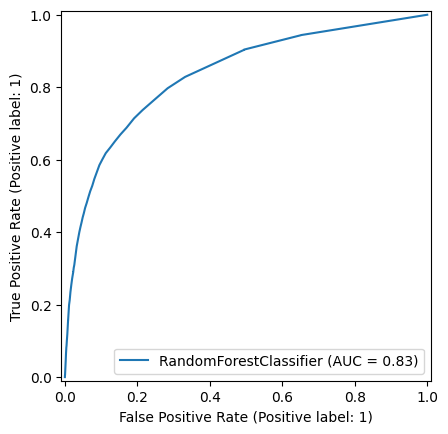

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.savefig('roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()

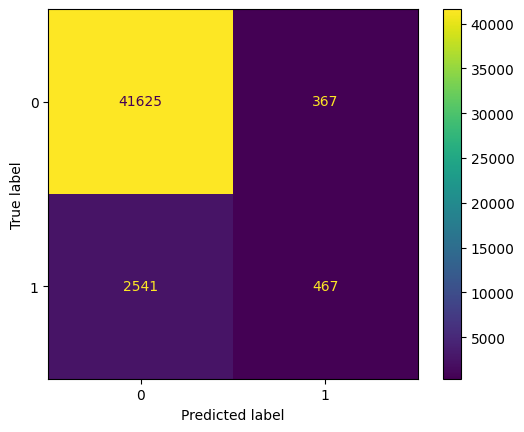

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
baseline_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"AUC baseline : {baseline_auc:.4f}")

import json
import requests

API_PROVIDER = "openrouter"
API_KEY = "mettre votre clé"
API_URL = "https://openrouter.ai/api/v1/chat/completions"
MODEL = "openrouter/free"

def call_llm(system_prompt, user_prompt, max_tokens=1000):
    headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
    body = {
        "model": MODEL,
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        "max_tokens": max_tokens,
    }
    r = requests.post(API_URL, headers=headers, json=body, timeout=60)
    print("Status:", r.status_code)
    print("Réponse:", r.text)
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"]

AUC baseline : 0.8343


In [ ]:
def generate_hypotheses(previous_results, n=4):
    system_prompt = (
        "Tu es un data scientist senior spécialisé en scoring de crédit. "
        "Tu proposes des features dérivées à tester pour améliorer un modèle de prédiction "
        "de défaut de paiement. Réponds UNIQUEMENT avec un JSON valide, sans texte autour."
    )
    user_prompt = f"""Variables disponibles :
{list(X.columns)}

Résultats déjà obtenus : {previous_results if previous_results else "Aucun run précédent."}

Propose {n} nouvelles features dérivées à tester (transformations, ratios, croisements de variables).
Réponds avec ce format JSON (liste de {n} objets) :
[
  {{"name": "nom_court", "formula": "description précise du calcul", "rationale": "pourquoi ça pourrait être prédictif"}}
]"""
    raw = call_llm(system_prompt, user_prompt)
    return raw

# Test
result = generate_hypotheses([])
print(result)

Status: 200
Réponse: 
         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         


In [ ]:
# --- Les 4 features proposées, traduites en code ---
FEATURE_BUILDERS = {
    "total_past_due": lambda d: (
        d["NumberOfTime30-59DaysPastDueNotWorse"]
        + d["NumberOfTime60-89DaysPastDueNotWorse"]
        + d["NumberOfTimes90DaysLate"]
    ),
    "income_per_dependent": lambda d: d["MonthlyIncome"] / (d["NumberOfDependents"] + 1),
    "real_estate_loan_ratio": lambda d: d["NumberRealEstateLoansOrLines"] / (d["NumberOfOpenCreditLinesAndLoans"] + 1),
    "severe_delinquency_flag": lambda d: (d["NumberOfTimes90DaysLate"] > 0).astype(int),
}

def train_variant(feature_name):
    X_aug = X.copy()
    X_aug[feature_name] = FEATURE_BUILDERS[feature_name](X_aug)
    X_tr, X_te, y_tr, y_te = train_test_split(X_aug, y, test_size=0.3, stratify=y, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    return roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

# Test sur la première feature
auc = train_variant("total_past_due")
print(f"AUC avec total_past_due : {auc:.4f} (baseline {baseline_auc:.4f}, gain {auc - baseline_auc:+.4f})")

AUC avec total_past_due : 0.8415 (baseline 0.8343, gain +0.0072)


In [ ]:
for name in FEATURE_BUILDERS:
    if name == "total_past_due":
        continue  # déjà fait
    auc = train_variant(name)
    print(f"AUC avec {name} : {auc:.4f} (baseline {baseline_auc:.4f}, gain {auc - baseline_auc:+.4f})")

AUC avec income_per_dependent : 0.8403 (baseline 0.8343, gain +0.0060)
AUC avec real_estate_loan_ratio : 0.8387 (baseline 0.8343, gain +0.0045)
AUC avec severe_delinquency_flag : 0.8390 (baseline 0.8343, gain +0.0047)


In [ ]:
def critique_result(name, formula, rationale, auc_obtained, baseline_auc):
    system_prompt = (
        "Tu es un reviewer statistique exigeant, spécialisé en risque de crédit. "
        "Ton rôle est de détecter les faux gains de performance : fuite de données, "
        "sur-ajustement, artefacts liés au déséquilibre de classe. "
        "Tu dois être capable de REJETER un résultat même s'il améliore l'AUC — "
        "un gain d'AUC n'est pas une preuve de validité. "
        "Réponds UNIQUEMENT avec un JSON valide, sans texte autour, sans explication de ton raisonnement."
    )
    user_prompt = f"""Feature testée : {name}
Formule : {formula}
Justification donnée : {rationale}

AUC baseline (sans cette feature) : {baseline_auc:.4f}
AUC obtenu avec cette feature : {auc_obtained:.4f}
Gain : {auc_obtained - baseline_auc:+.4f}

Contexte : dataset de 150 000 emprunteurs, 6.7% de défauts (classe minoritaire).

Analyse ces 3 points puis rends un verdict :
1. Fuite de données : cette feature encode-t-elle une info connue seulement APRÈS la décision de crédit ?
2. Gain suspect : le gain d'AUC est-il disproportionné vu le déséquilibre de classe ?
3. Cohérence métier : la feature a-t-elle un sens économique réel ?

Réponds directement avec ce format JSON, sans rien d'autre :
{{"data_leakage_risk": "faible|moyen|élevé", "leakage_reasoning": "...", "gain_plausible": true, "gain_reasoning": "...", "business_coherent": true, "verdict": "accepté|rejeté", "final_reasoning": "..."}}"""
    raw = call_llm(system_prompt, user_prompt, max_tokens=3000)
    return raw

verdict = critique_result(
    "total_past_due",
    "NumberOfTime30-59DaysPastDueNotWorse + NumberOfTime60-89DaysPastDueNotWorse + NumberOfTimes90DaysLate",
    "Agrège l'historique complet de retards de paiement, capture la fréquence globale des incidents de remboursement.",
    0.8415,
    baseline_auc
)
print(verdict)

Status: 200
Réponse: 
         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         
{"id":"gen-1786962378-F8tSABBZH59ISn0FqIRV","object":"chat.completion","created":1786962378,"model":"nvidia/nemotron-3-super-120b-a12b:free","p

In [ ]:
remaining = {
    "income_per_dependent": (
        "MonthlyIncome / (NumberOfDependents + 1)",
        "Mesure le revenu disponible par personne à charge, indicateur de capacité de remboursement ajusté aux obligations familiales.",
        0.8403
    ),
    "real_estate_loan_ratio": (
        "NumberRealEstateLoansOrLines / (NumberOfOpenCreditLinesAndLoans + 1)",
        "Proportion de crédits immobiliers dans le portefeuille total, reflète la stabilité de l'endettement.",
        0.8387
    ),
    "severe_delinquency_flag": (
        "1 if NumberOfTimes90DaysLate > 0 else 0",
        "Indicateur binaire de défaut sévère passé, signal fort de risque de récidive.",
        0.8390
    ),
}

verdicts = {}
for name, (formula, rationale, auc) in remaining.items():
    print(f"\n=== {name} ===")
    v = critique_result(name, formula, rationale, auc, baseline_auc)
    print(v)
    verdicts[name] = v


=== income_per_dependent ===
Status: 200
Réponse: 
         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         

         
{"id":"gen-1786962503-1EQsiCdjTKuEiU0xKkne","object":"chat.completion","created":1786962503,"model":"nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free","provider":"Nvidia","system_fingerprint":null,"service_tier":null,"choices":[{"index":0,"logprobs":null,"finish_reason":"stop","native_finish_reason":"stop","message":{"role":"assistant","content":"{\n  \"data_leakage_risk\": \"faible\",\n  \"leakage_reasoning\": \"La feature utilise uniquement des v